<table style="width:100%;">
  <tr>
    <td style="text-align:left;"><strong>Data Science Internship Program</strong></td>
    <td style="text-align:right;"><strong>ORGANIZATION :</strong> CodeAlpha</td>
  </tr>
  <tr>
    <td style="text-align:left;"><strong>STUDENT NAME :</strong> Jomi Jose</td>
    <td style="text-align:right;"><strong>STUDENT ID :</strong> CA/FE3/10513</td>
  </tr>
</table>


# Iris Flower Classification:
### __________________________________________________________________________________ ###

## 1. Project Overview:
-----------------------------

The Iris flower classification is a fundamental machine learning task that involves categorizing iris flowers into three species: **Setosa, Versicolor, and Virginica**, based on their sepal and petal measurements. This project aims to develop a machine learning model that learns from these measurements to accurately classify new iris samples. By utilizing classification algorithms, this project demonstrates the application of supervised learning in pattern recognition and species identification.

### __________________________________________________________________________________ ###

## 2. Problem Statement:
---------------------------------

The task at hand is to develop a machine learning model that accurately classifies iris flowers based on their sepal and petal measurements into one of three species: Setosa, Versicolor, or Virginica. Although there are existing datasets available, creating an effective model requires careful selection of features, the choice of an appropriate algorithm, and optimization of the model's performance. The objective is to build a reliable classification model that can generalize well to new data, demonstrating the power of machine learning in biological classification tasks.

### ___________________________________________________________________________________ ###

 ### 2.1 Dataset Details :
 --------------------------
  
    Data Set features are shown below :
    ___________________________________________________________________________________________________________
    Id              :  A unique number assigned to each flower sample.
    SepalLengthCm	:  Length of the sepal in centimeters.
    SepalWidthCm	:  Width of the sepal in centimeters.
    PetalLengthCm	:  Length of the petal in centimeters.
    PetalWidthCm	:  Width of the petal in centimeters.
    Species         :  The type of Iris flower (Setosa, Versicolor, or Virginica). 

 
**Key point:** *The "Id" is simply a way to identify individual data points within the dataset, while the other columns represent the actual measurements used to classify the Iris species.*


In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid') 
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,ConfusionMatrixDisplay


In [2]:
Iris_df = pd.read_csv("C://Users//jomij//OneDrive - University of Sussex//Desktop//CodeAlpha//Task//Data Science//Task 1//archive//Iris.csv")

In [3]:
Iris_df.head() #To check the data 

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
Iris_df.info() #to get the information about the data we have

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


#### DataFrame Overview:
------------------------------------

* The Iris_df dataframe consists of 150 data entries.

* Analysis of the data reveals no null or missing values.

* The dataframe contains six features: Id, SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm, and Species.

* The features are comprised of four numerical variables (Float64) and one categorical variable (Object).

## 3. Exploratory Data Analysis(EDA) :
_________________________________________________

### 3.1 Statistics  Summary:
------------------------------------

In [5]:
Iris_df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


_________________________________________________________________________

<span style="color:blue; font-size: 16px;">**Observations :**</span>
_______________

- *The data reveals the following ranges: Sepal length (4.3 - 7.9 cm), Sepal width (2.0 - 4.4 cm), Petal length (1.0 - 6.9 cm), and Petal width (0.1 - 2.5 cm). We will now analyze the distribution of these measurements across the different species.*

___________________________________________________________________________

The subsequent analysis will focus on the distribution of data across the species in the dataframe.

In [6]:
Species_count = Iris_df["Species"].value_counts()
Species_count

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

___________________________________________________________________________________
<span style="color:blue; font-size: 16px;">**Observations :**</span>
__________________

* The data shows an equal distribution of all three species, indicating a balanced dataset.

__________________________________________________________________________________

In [7]:
Iris_df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
145    False
146    False
147    False
148    False
149    False
Length: 150, dtype: bool

-------------------------------------------------------

<span style="color:blue; font-size: 16px;">**Observations :**</span>
___________________________________________________________________

* The data contains no duplicate entries, indicating a clean dataset. Therefore, no further data cleaning is required in this instance.

--------------------------------------

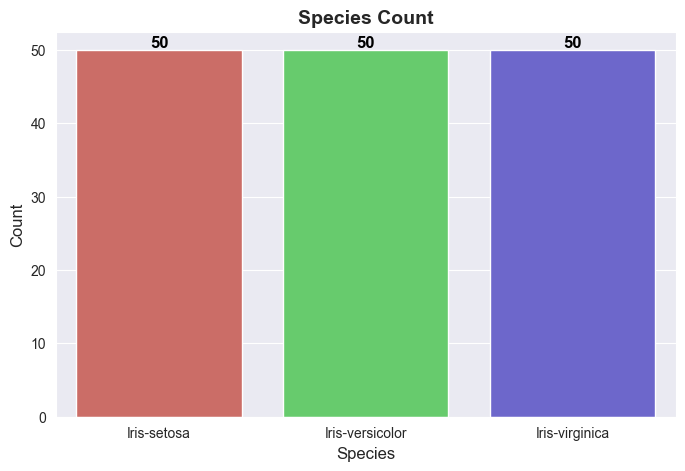

In [8]:
# Create count plot
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Species',hue='Species', data=Iris_df, palette='hls', legend=False)  

# Label each bar with the count
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

# Titles and labels
plt.title('Species Count', fontsize=14, fontweight='bold')
plt.xlabel('Species', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Show plot
plt.show()

---------------------------------------------------------------------------------
### 3.2 Analysis of Various Species Based on Sepal Length and Width:
---------------------------------------------------------------------------------

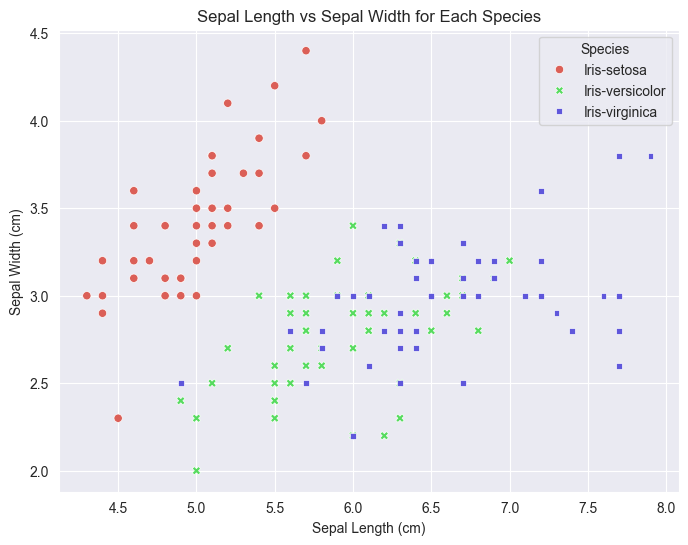

In [9]:
# Scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x='SepalLengthCm', y='SepalWidthCm', hue='Species', style='Species', data=Iris_df, palette='hls')

# Labels and title
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.title("Sepal Length vs Sepal Width for Each Species")
plt.legend(title="Species")

# Show plot
plt.show()



<span style="color:blue; font-size: 16px;">**Observations :**</span>
___________________________________________________________________

From the scatter plot, we observe:

- Iris-setosa is characterized by shorter sepal lengths and relatively larger sepal widths, as evidenced by its concentration in the upper-left area.

- Iris-versicolor occupies a central position, indicating sepal length and width values that are neither exceptionally high nor low.

- Iris-virginica tends to have longer sepal lengths and narrower sepal widths, resulting in its placement towards the right-middle portion of the plot.

- The close proximity of Iris-versicolor and Iris-virginica suggests a high degree of overlap, which could pose a challenge for classification based on these two features alone

### __________________________________________________________________________________________ ###


______________________________________________________________________________
### 3.3 Analysis of Various Species Based on Petal Length and Width:
______________________________________________________________________________

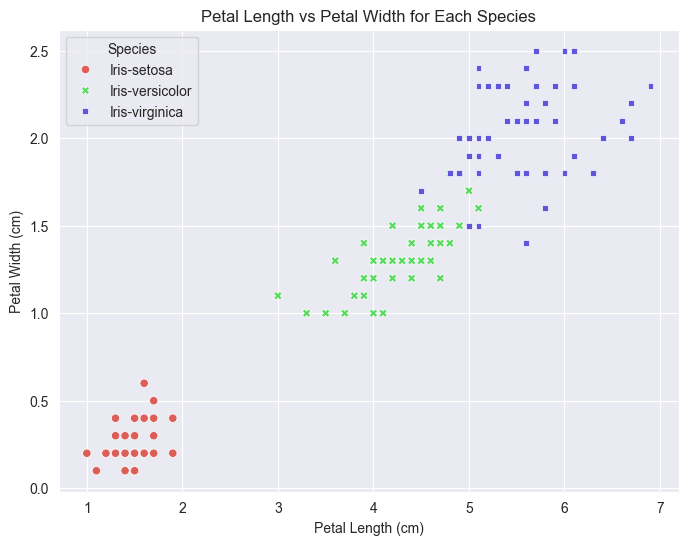

In [10]:
# Scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PetalLengthCm', y='PetalWidthCm', hue='Species', style='Species', data=Iris_df, palette='hls')

# Labels and title
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Petal Length vs Petal Width for Each Species")
plt.legend(title="Species")

# Show plot
plt.show()


<span style="color:blue; font-size: 16px;">**Observations :**</span>
____________________________________________________________________

From the scatter plot, we can conclude:

-  Iris-setosa is characterized by significantly smaller petal lengths and widths, concentrated in the lower-left area.

-  Iris-versicolor exhibits petal lengths and widths within an intermediate range, placing it in the central portion of the plot.

-  Iris-virginica is distinguished by its larger petal lengths and widths, evident in its clustering towards the upper-right.

-  The scatter plot demonstrates a greater degree of separation between species based on petal dimensions compared to sepal dimensions.
 ###   ________________________________________________________________________________________ ###

### 3.4 Pair Plot :
___________________________

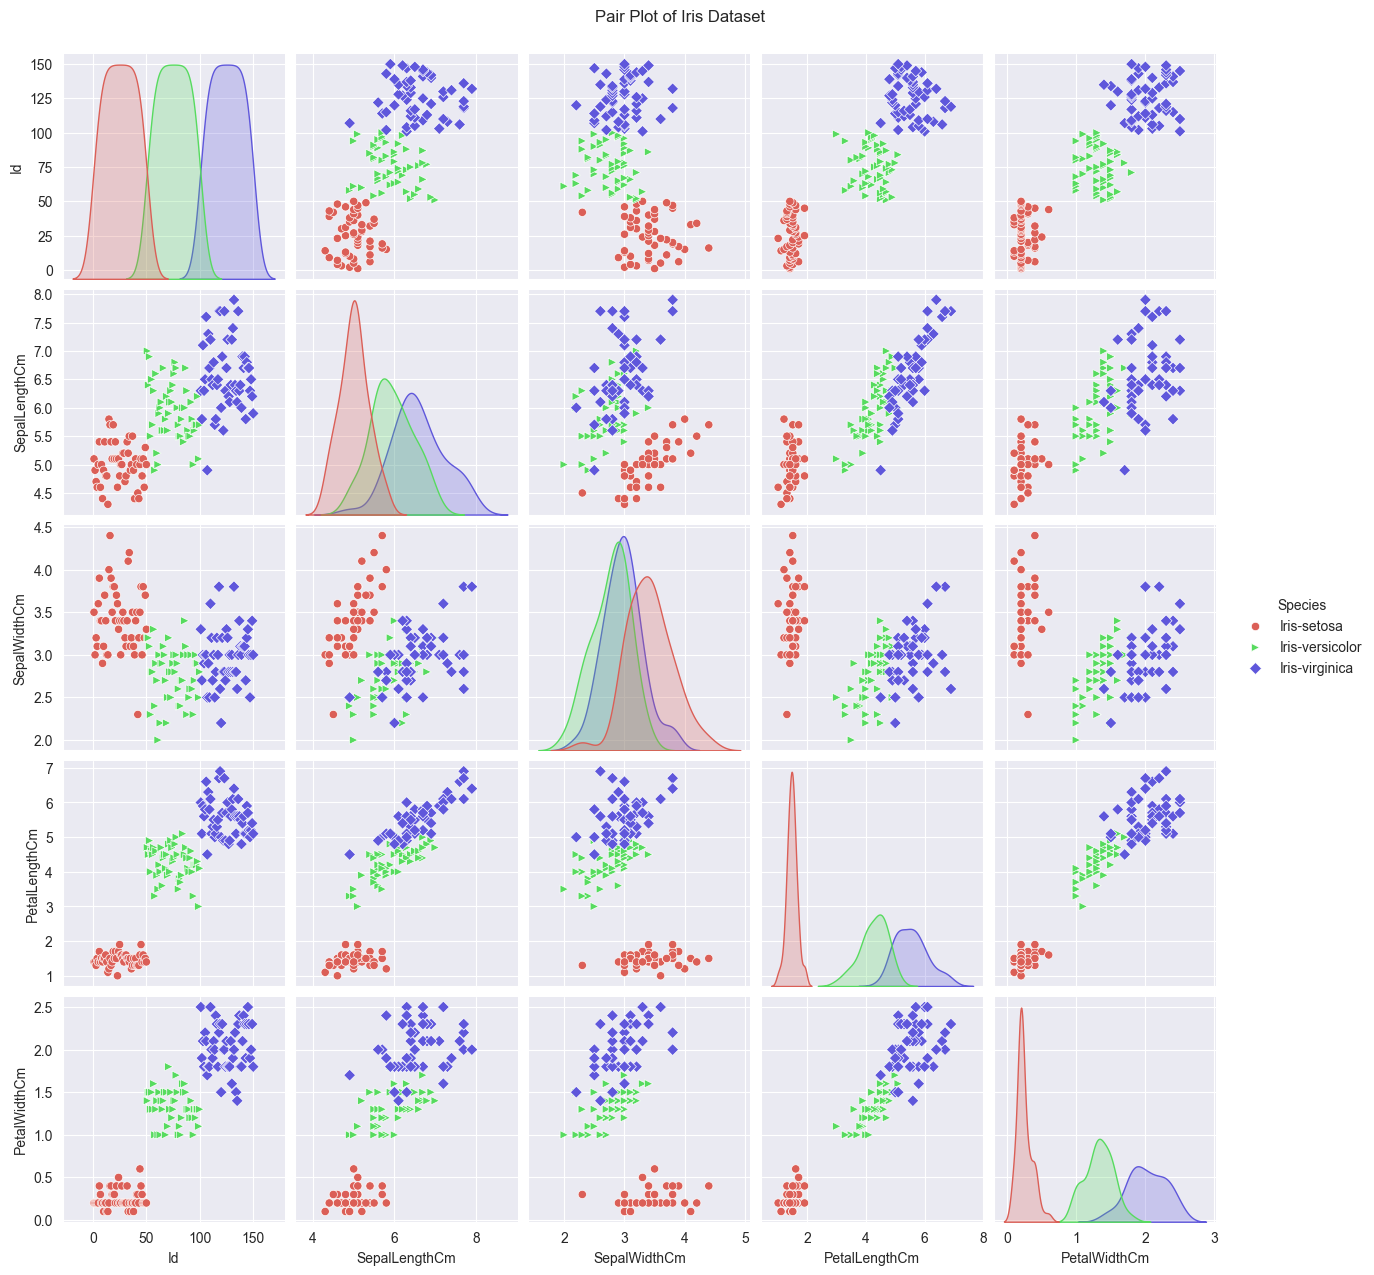

In [11]:
sns.pairplot(Iris_df, hue='Species', palette='hls', markers=['o', '>', 'D'])

# Add a title to the plot
plt.suptitle('Pair Plot of Iris Dataset', y=1.02)

# Show the plot
plt.show()

-------------------------------------------
### 3.5 Correlation Heatmap :
-------------------------------------------



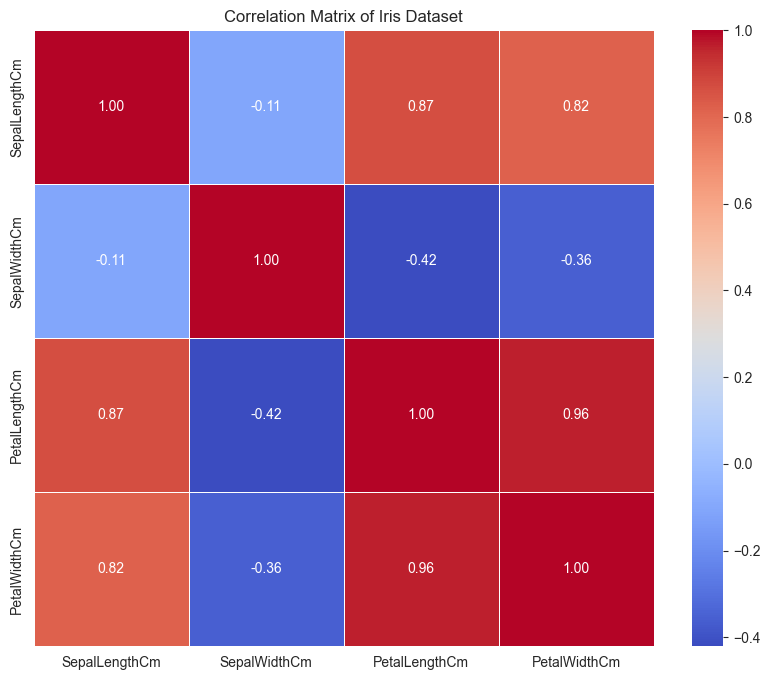

In [12]:
# Select only the numeric columns
numeric_df = Iris_df.select_dtypes(include=['float64'])

# Compute the correlation matrix
corr_matrix = numeric_df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# Add title
plt.title('Correlation Matrix of Iris Dataset')

# Show plot
plt.show()


___________________________________

<span style="color:blue; font-size: 16px;">**Observations :**</span>
___________________________________________________________________

- Petal length and petal width are highly correlated, indicating that they may provide redundant information for some analysis tasks.

- Sepal length and petal length also exhibit a strong positive correlation, suggesting a general size trend in Iris flowers.

- Sepal width has a weak correlation with sepal length and a moderate negative correlation with petal length and width

______________________________________________________________________

______________________________________________________________
### 3.6 Analysing Distribution for each Species:
______________________________________________________________

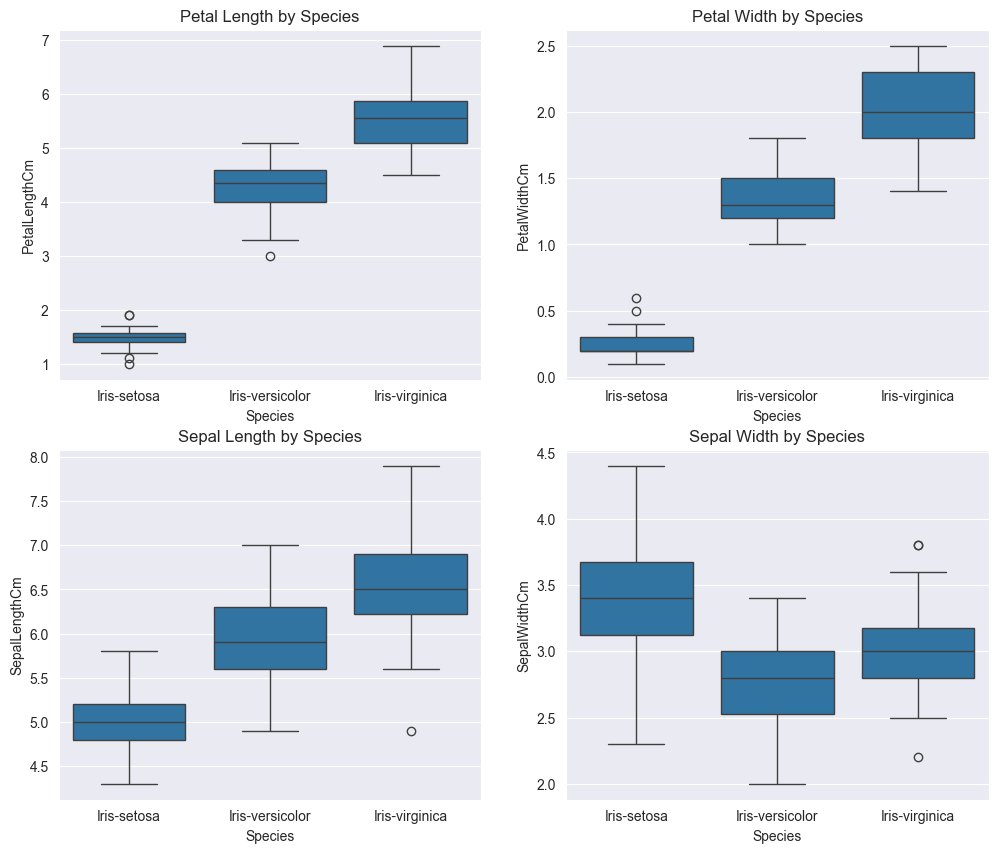

In [13]:
fig, axes = plt.subplots(2,2, figsize=(12,10))
sns.boxplot(Iris_df, x="Species", y="PetalLengthCm",ax=axes[0,0])
axes[0, 0].set_title("Petal Length by Species")

sns.boxplot(Iris_df, x="Species", y="PetalWidthCm", ax=axes[0,1])
axes[0, 1].set_title("Petal Width by Species")

sns.boxplot(Iris_df, x="Species", y="SepalLengthCm", ax=axes[1,0])
axes[1, 0].set_title("Sepal Length by Species")

sns.boxplot(Iris_df, x="Species", y="SepalWidthCm", ax=axes[1,1])
axes[1, 1].set_title("Sepal Width by Species")


# Show plot
plt.show()


________________________________________________________________________
<span style="color:blue; font-size: 16px;">**Observations :**</span>
___________________________________________________________________________
Based on the box plots shown in the image, here are the key findings:

#### Petal Length by Species
------------------------------

* Iris-setosa has significantly smaller petal lengths compared to the other two species.

* Iris-versicolor has petal lengths in the mid-range.

* Iris-virginica has the largest petal lengths.

* There is a clear distinction between the three species based on petal length.

#### Petal Width by Species:
------------------------------

* Iris-setosa has the smallest petal width with very little variation.

* Iris-versicolor shows an intermediate range of petal widths.

* Iris-virginica has the largest petal width.

* There are some outliers in Iris-setosa.

#### Sepal Length by Species:
-------------------------------

* Iris-setosa has the smallest sepal length.

* Iris-virginica has the longest sepal length, followed by Iris-versicolor.

* There are slight overlaps between Iris-versicolor and Iris-virginica, meaning sepal length alone may not be the best distinguishing factor.

#### Sepal Width by Species:
--------------------------------

* Iris-setosa has the highest median sepal width.

* Iris-versicolor has the lowest sepal width.

* Iris-virginica shows more variation in sepal width.

* There are a few outliers in Iris-virginica.

#### Key Insights:
--------------------------------

* Petal length and petal width are strong distinguishing factors among the three species, with clear separation.

* Sepal length and sepal width show some overlap between species, making them less effective as standalone distinguishing features.

* The presence of outliers in petal width and sepal width for some species suggests variability within the dataset.


--------------------------------------------
### 3.7 Baseline Prediction:
__________________________________________

In [38]:
Iris_df.Species.value_counts(normalize = True)

Species
Iris-setosa        0.333333
Iris-versicolor    0.333333
Iris-virginica     0.333333
Name: proportion, dtype: float64

________________________________________________________________________________________________
#### Balanced Class Distribution & Baseline Prediction in the Iris Dataset:

The Iris dataset has an equal distribution of species: Iris-setosa, Iris-versicolor, and Iris-virginica. Each species makes up 33.33% of the data. This balance helps train models fairly and reduces bias in classification tasks.

A baseline prediction helps us assess how well a model is performing. For example, if we classify every instance as Iris-setosa, we would achieve 33.33% accuracy, which is the same as random guessing. Any model that performs better than this shows that it has learned something useful.

Setting a baseline is important in machine learning because it establishes a minimum standard. A model that reaches 95% accuracy clearly does much better than random guessing, showing that it can effectively recognize patterns.
### ________________________________________________________________________________________ ###


--------------------------------------

## 4 Data Prepration & Model Training:
-----------------------------------------------------

- Before training our machine learning model, we split the dataset into an 80% training set and a 20% testing set.
- We chose three machine learning methods: KNN, Logistic Regression, and Decision Tree. Our goal is to find out which model works best for classifying Iris flowers

----------------------------------------------------


In [15]:
X = Iris_df.drop('Species', axis=1)
y = Iris_df['Species']

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

#scaler = StandardScaler()
#X_train = scaler.fit_transform(X_train)
#X_test = scaler.transform(X_test)

In [30]:
print(y_train.value_counts())  # Check training class distribution
print(y_test.value_counts())  # Check test class distribution

Species
Iris-versicolor    41
Iris-setosa        40
Iris-virginica     39
Name: count, dtype: int64
Species
Iris-virginica     11
Iris-setosa        10
Iris-versicolor     9
Name: count, dtype: int64


In [16]:
#KNN Model:

# Define the pipeline
model_knn = Pipeline([
    ('scaler', StandardScaler()),          # Step 1: Scale features
    ('knn', KNeighborsClassifier(n_neighbors=5))  # Step 2: KNN classifier
])

# Fit the pipeline on the training data
model_knn.fit(X_train, y_train)

# Make predictions
predictions_knn = model_knn.predict(X_test)


In [17]:
# Logistic Regression:

model_lr = make_pipeline(StandardScaler(), LogisticRegression(solver='lbfgs', max_iter=200))

# Fit the pipeline on the training data
model_lr.fit(X_train, y_train)

# Make predictions
predictions_lr = model_lr.predict(X_test)

In [18]:
#Decision Tree:

model_dt = Pipeline([
    ('scaler', StandardScaler()),  # Step 1: Scale features
    ('dt', DecisionTreeClassifier(random_state=42))  # Step 2: Decision Tree classifier
])
model_dt.fit(X_train, y_train)
# Make predictions
predictions_dt   =model_dt.predict(X_test)

 ### _________________________________________________________________________________ ###

## 5. Model Evaluation:
-------------------------------

Evaluating the performance of machine learning models involves several key metrics that provide insights into the model's effectiveness. Here's an overview of these metrics:

* $Confusion Matrix:$ This table summarizes the performance of a classification algorithm by displaying the actual versus predicted classifications. It comprises four components:


   - **True Positives (TP):** Correctly predicted positive instances.

   - **True Negatives (TN):** Correctly predicted negative instances.

   - **False Positives (FP):** Incorrectly predicted positive instances.

   - **False Negatives (FN):** Incorrectly predicted negative instances.



- $Accuracy$ measures the proportion of correctly predicted instances (both positive and negative) out of the total instances.

$$ \\Text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}\ $$


- $Precision:$ Precision indicates the proportion of correctly predicted positive instances out of all instances predicted as positive. 

$$\\text{Precision} = \frac{TP}{TP + FP}\$$
 

- $Recall (Sensitivity):$ Recall, or sensitivity, measures the proportion of correctly predicted positive instances out of all actual positive instances. 

$$\\text{Recall} = \frac{TP}{TP + FN}\$$
 

- $F1-Score:$ The F1-score is the harmonic mean of precision and recall, providing a balance between the two metrics. 

$$\\text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}\$$

 

- $Cross-Validation Scores:$ Cross-validation involves partitioning the dataset into subsets, training the model on some subsets, and validating it on others. This process helps assess the model's generalizability.  Here we use the k-fold cross-validation, where the dataset is divided into 'k' subsets, and the model is trained and validated 'k' times, each time using a different subset as the validation set.


_____________________________
### 5.1 Confusion Matrix:
-------------------------------

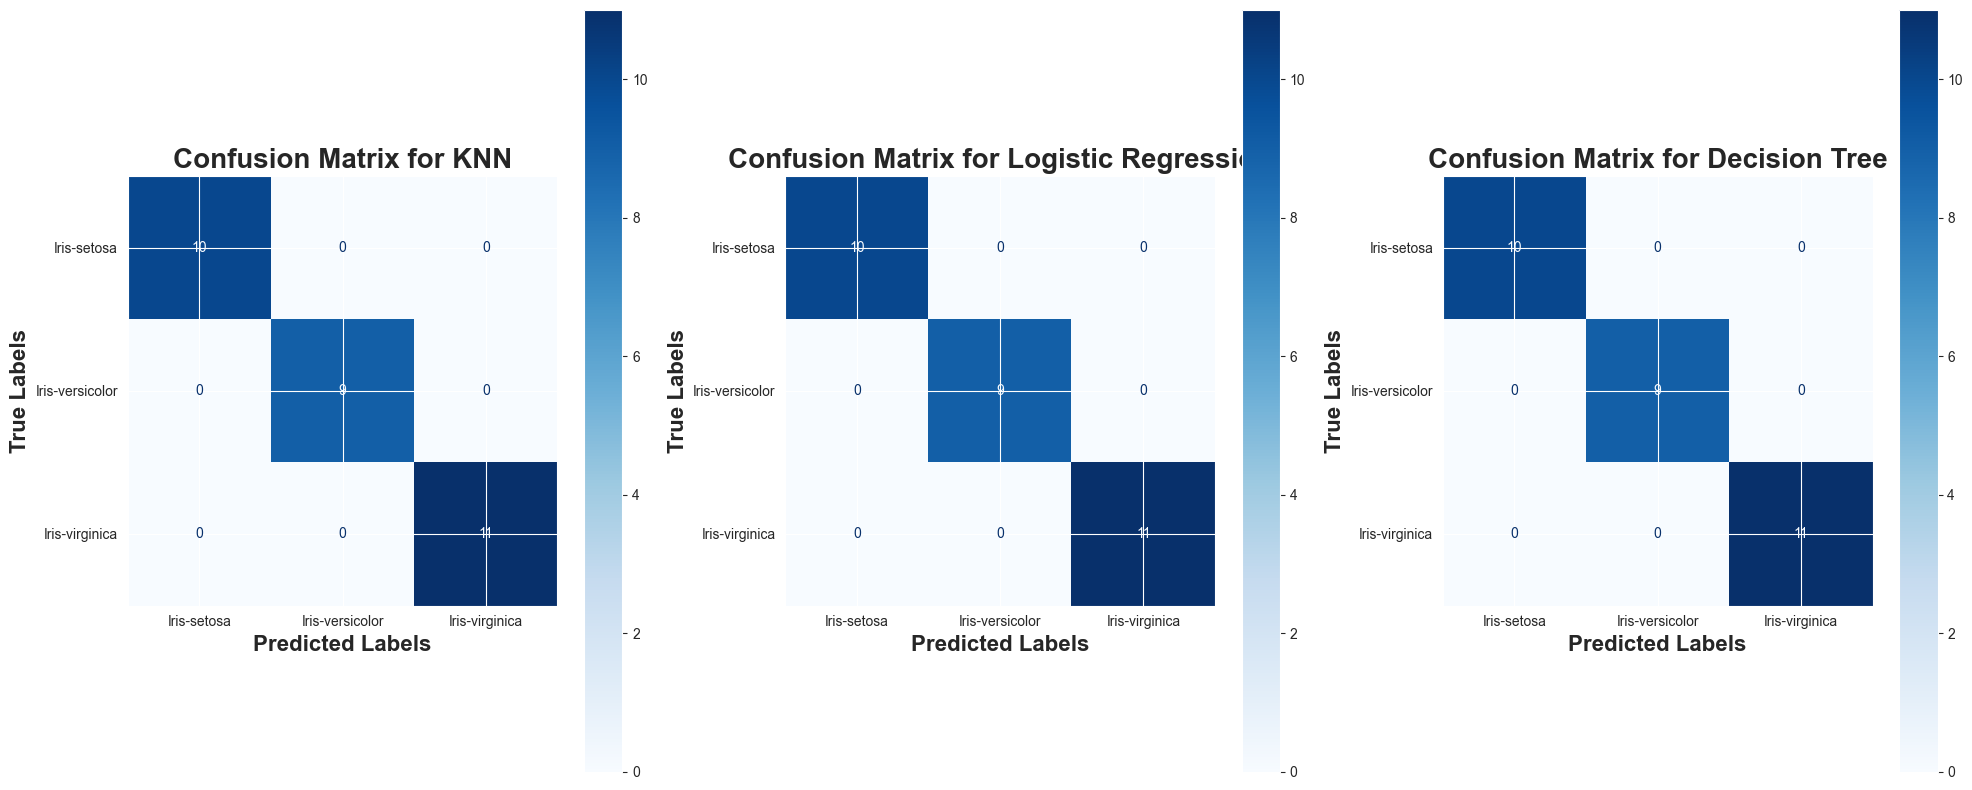

In [19]:

fig, axes = plt.subplots(1, 3, figsize=(20, 8))  # Create 3 subplots

# Confusion Matrix for KNN
cm_knn = confusion_matrix(y_test, predictions_knn, labels=model_knn.classes_)
ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=model_knn.classes_).plot(ax=axes[0], cmap=plt.cm.Blues)
axes[0].set_title('Confusion Matrix for KNN', fontsize=20,fontweight='bold')
axes[0].set_xlabel('Predicted Labels', fontsize=16, fontweight='bold')
axes[0].set_ylabel('True Labels', fontsize=16, fontweight='bold')

# Confusion Matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, predictions_lr, labels=model_lr.classes_)
ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=model_lr.classes_).plot(ax=axes[1], cmap=plt.cm.Blues)
axes[1].set_title('Confusion Matrix for Logistic Regression', fontsize=20,fontweight='bold')
axes[1].set_xlabel('Predicted Labels', fontsize=16, fontweight='bold')
axes[1].set_ylabel('True Labels', fontsize=16, fontweight='bold')

# Confusion Matrix for Decision Tree
cm_dt = confusion_matrix(y_test, predictions_dt, labels=model_dt.classes_)
ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=model_dt.classes_).plot(ax=axes[2], cmap=plt.cm.Blues)
axes[2].set_title('Confusion Matrix for Decision Tree', fontsize=20,fontweight='bold')
axes[2].set_xlabel('Predicted Labels', fontsize=16, fontweight='bold')
axes[2].set_ylabel('True Labels', fontsize=16, fontweight='bold')

plt.tight_layout()  # Adjust layout for better spacing
plt.show()

### 5.2 Classification Report:
-------------------------------------

In [20]:
# Classification report for KNN
y_pred_knn = model_knn.predict(X_test)
report_knn = classification_report(y_test, y_pred_knn, output_dict=True)
df_knn = pd.DataFrame(report_knn).transpose()  # Convert to DataFrame
print("\nClassification Report for KNN:\n", df_knn)

# Classification report for Logistic Regression
y_pred_lr = model_lr.predict(X_test)
report_lr = classification_report(y_test, y_pred_lr, output_dict=True)
df_lr = pd.DataFrame(report_lr).transpose()
print("\nClassification Report for Logistic Regression:\n", df_lr)

# Classification report for Decision Tree
y_pred_dt = model_dt.predict(X_test)
report_dt = classification_report(y_test, y_pred_dt, output_dict=True)
df_dt = pd.DataFrame(report_dt).transpose()
print("\nClassification Report for Decision Tree:\n", df_dt)


Classification Report for KNN:
                  precision  recall  f1-score  support
Iris-setosa            1.0     1.0       1.0     10.0
Iris-versicolor        1.0     1.0       1.0      9.0
Iris-virginica         1.0     1.0       1.0     11.0
accuracy               1.0     1.0       1.0      1.0
macro avg              1.0     1.0       1.0     30.0
weighted avg           1.0     1.0       1.0     30.0

Classification Report for Logistic Regression:
                  precision  recall  f1-score  support
Iris-setosa            1.0     1.0       1.0     10.0
Iris-versicolor        1.0     1.0       1.0      9.0
Iris-virginica         1.0     1.0       1.0     11.0
accuracy               1.0     1.0       1.0      1.0
macro avg              1.0     1.0       1.0     30.0
weighted avg           1.0     1.0       1.0     30.0

Classification Report for Decision Tree:
                  precision  recall  f1-score  support
Iris-setosa            1.0     1.0       1.0     10.0
Iris-versic

### 5.3 Accuracy:
------------------------------

In [21]:
# Calculate and print the accuracy for KNN
accuracy_knn = accuracy_score(y_test, predictions_knn)
print('Accuracy KNN:', accuracy_knn)

Accuracy KNN: 1.0


In [22]:
# Calculate and print the accuracy for Logistic Regression
accuracy_lr = accuracy_score(y_test, predictions_lr)
print('Accuracy Logistic regression:', accuracy_lr)

Accuracy Logistic regression: 1.0


In [23]:
# Calculate and print the accuracy for Logistic Regression
accuracy_dt = accuracy_score(y_test, predictions_dt)
print('Accuracy Logistic regression:', accuracy_dt)

Accuracy Logistic regression: 1.0


### 5.4 Cross-Validation :
-------------------------------

We utilized 10-fold cross-validation to evaluate the models performance more reliably. This method splits the dataset into 10 subsets (folds), where the model is trained on 9 folds and validated on the remaining fold, repeating this process 10 times to ensure each subset is used for validation once.

The cross-validation accuracy scores for each iteration are recorded, and their mean accuracy provides a more robust estimate of model performance. This approach reduces the risk of overfitting and ensures that our model is evaluated on multiple data splits, leading to a more generalizable and unbiased assessment.

In [24]:
# Perform 10-fold cross-validation for KNN Model
cv_scores_knn = cross_val_score(model_knn, X, y, cv=10, scoring='accuracy')
mean_cv_knn = cv_scores_knn.mean() * 100
print('Cross-Validation Accuracy Scores of KNN :', cv_scores_knn)


Cross-Validation Accuracy Scores of KNN : [1.         0.93333333 1.         1.         1.         1.
 1.         1.         1.         1.        ]


In [25]:
# Perform 10-fold cross-validation for Logistic Regression
cv_scores_lr = cross_val_score(model_lr, X, y, cv=10, scoring='accuracy')
mean_cv_lr = cv_scores_lr.mean() * 100
print('Cross-Validation Accuracy Scores Logistic Regression:', cv_scores_lr)


Cross-Validation Accuracy Scores Logistic Regression: [1.         0.93333333 1.         1.         1.         1.
 1.         1.         1.         1.        ]


In [26]:
# Perform 10-fold cross-validation for Decision Tree
cv_scores_dt = cross_val_score(model_dt, X, y, cv=10, scoring='accuracy')
mean_cv_dt = cv_scores_dt.mean() * 100
print('Cross-Validation Accuracy Scores Decision Tree:', cv_scores_dt)


Cross-Validation Accuracy Scores Decision Tree: [0.8        1.         1.         1.         1.         1.
 1.         1.         1.         0.86666667]


In [27]:

# Create a DataFrame to compare the results
accuracy_comparison_df = pd.DataFrame({
    'Model': ['K-Nearest Neighbors', 'Logistic Regression', 'Decision Tree'],
    'Mean Accuracy (%)': [mean_cv_knn, mean_cv_lr, mean_cv_dt]
})

# Display the comparison DataFrame
accuracy_comparison_df

,Model,Mean Accuracy (%)
0,K-Nearest Neighbors,99.333333
1,Logistic Regression,99.333333
2,Decision Tree,96.666667


-------------------------------------------------------------------------------------------
-  All three models (KNN, Logistic Regression, and Decision Tree) achieved 100% precision, recall, and F1-score for each Iris species.

-  This indicates that every test sample was classified correctly, with no misclassifications.


-  KNN and Logistic Regression both achieved a mean accuracy of 99.33%, while the Decision Tree model slightly lagged at 96.67%.

-  The slight drop in Decision Tree accuracy might be due to overfitting or sensitivity to small variations in the data.


### _______________________________________________________________________________________ ###


---------------------------------------------------------
## 6. Predicting the Iris flower classification(KNN, Logistic Regression, Decision Tree):
----------------------------------------------------------------------------------------------------------------------
* The test dataset, which has been kept separate during training, will now be used to assess the model's ability to generalize to unseen data. We will compare the predicted classifications with the actual values to evaluate the model's performance.

--------------------------------------------------------------


In [28]:
# Make predictions using different models
Iris_classification_knn = model_knn.predict(X_test)
Iris_classification_lr = model_lr.predict(X_test)
Iris_classification_dt = model_dt.predict(X_test)

# Create a combined DataFrame
comparison_df1 = pd.DataFrame({
    'actual': y_test,
    'KNN_predicted': Iris_classification_knn,
    'LR_predicted': Iris_classification_lr,
    'DT_predicted': Iris_classification_dt
})

# Add 'match' columns to check if predictions are correct
comparison_df1['KNN_match'] = comparison_df1['actual'] == comparison_df1['KNN_predicted']
comparison_df1['LR_match'] = comparison_df1['actual'] == comparison_df1['LR_predicted']
comparison_df1['DT_match'] = comparison_df1['actual'] == comparison_df1['DT_predicted']

# Reset index
comparison_df1.reset_index(drop=True, inplace=True)

# Display the combined DataFrame
comparison_df1

,actual,KNN_predicted,LR_predicted,DT_predicted,KNN_match,LR_match,DT_match
0,Iris-versicolor,Iris-versicolor,Iris-versicolor,Iris-versicolor,True,True,True
1,Iris-setosa,Iris-setosa,Iris-setosa,Iris-setosa,True,True,True
2,Iris-virginica,Iris-virginica,Iris-virginica,Iris-virginica,True,True,True
3,Iris-versicolor,Iris-versicolor,Iris-versicolor,Iris-versicolor,True,True,True
4,Iris-versicolor,Iris-versicolor,Iris-versicolor,Iris-versicolor,True,True,True
5,Iris-setosa,Iris-setosa,Iris-setosa,Iris-setosa,True,True,True
6,Iris-versicolor,Iris-versicolor,Iris-versicolor,Iris-versicolor,True,True,True
7,Iris-virginica,Iris-virginica,Iris-virginica,Iris-virginica,True,True,True
8,Iris-versicolor,Iris-versicolor,Iris-versicolor,Iris-versicolor,True,True,True
9,Iris-versicolor,Iris-versicolor,Iris-versicolor,Iris-versicolor,True,True,True


In [29]:
# Calculate accuracy for each model
knn_accuracy1 = accuracy_score(comparison_df1['actual'], comparison_df1['KNN_predicted'])
lr_accuracy1= accuracy_score(comparison_df1['actual'], comparison_df1['LR_predicted'])
dt_accuracy1 = accuracy_score(comparison_df1['actual'], comparison_df1['DT_predicted'])

# Create a DataFrame to compare the results
accuracy_comparison_df = pd.DataFrame({
    'Model Prediction': ['K-Nearest Neighbors', 'Logistic Regression', 'Decision Tree'],
    'Mean Accuracy (%)': [knn_accuracy1, lr_accuracy1, dt_accuracy1]
})
accuracy_comparison_df
# Display the comparison DataFrame
#comparison_df

# Print accuracy scores
#print(f"KNN Accuracy: {knn_accuracy1:.2f}")
#print(f"Logistic Regression Accuracy: {lr_accuracy1:.2f}")
#print(f"Decision Tree Accuracy: {dt_accuracy1:.2f}")

,Model Prediction,Mean Accuracy (%)
0,K-Nearest Neighbors,1.0
1,Logistic Regression,1.0
2,Decision Tree,1.0


### _______________________________________________________________________________________ ###

## 7 Conclusion:
--------------------

This study successfully applied K-Nearest Neighbors (KNN), Logistic Regression, and Decision Tree classifiers to the Iris dataset, which consists of 150 entries equally distributed among three species. 

From the scatter plot analysis, we observed the following:

 - There is a greater distinction between species based on petal dimensions than on sepal dimensions.

 - Iris-setosa is distinctly separable due to its unique sepal & petal dimensions.
 
 - Iris-versicolor and Iris-virginica show some overlap, but the dataset remains well-structured for classification.

All three models demonstrated exceptional performance, achieving nearly 100% accuracy in both the classification reports and cross-validation results:

  - KNN and Logistic Regression: 99.33% mean accuracy
  
  - Decision Tree: 96.67% mean accuracy

The near-perfect accuracy can be attributed to the simplicity and well-structured nature of the dataset. The clear distinctions in feature values across species allow for effective classification without the need for complex models or extensive feature engineering. 

Additionally, the final predictions confirmed that all models accurately classified each instance, reinforcing their effectiveness. 

By implementing 10-fold cross-validation, we ensured a robust and unbiased evaluation, reducing the risk of overfitting and improving model reliability. Based on these findings, we conclude that KNN and Logistic Regression are the most optimal models for classifying Iris species due to their superior accuracy and consistency.

This project highlights the importance of data simplicity, visualization, model evaluation, and cross-validation in building reliable classification models. Future work can explore additional features, hyperparameter tuning, or ensemble learning for further optimization.


### _____________________________________________________________________________________ ###



## ___________________________________________________________________________ ##